# Automatisation de la recherche des hyperparamètres avec GridSearchCV

## Le problème

On sait qu'on peut **améliorer** un modèle en jouant sur ses hyperparamètres (`max_depth`, `min_samples_leaf`, `max_features`...). Mais le faire **à la main** est très laborieux :

- On essaie une valeur, on mesure, on note.
- On essaie une autre valeur, on mesure, on note.
- On essaie une **combinaison** de deux hyperparamètres... et là ça explose.

Pour 4 valeurs de `max_depth` × 2 valeurs de `max_features` × 10 folds de cross-validation, on a déjà **80 entraînements** à lancer. Impossible de suivre manuellement.

> **La solution :** `GridSearchCV` automatise ce processus. On lui donne une **grille** de valeurs à tester pour chaque hyperparamètre, une métrique, et un nombre de folds. Il s'occupe d'essayer **toutes les combinaisons**, de faire une cross-validation pour chacune, et de nous rendre la meilleure.

Le `CV` dans `GridSearchCV` veut dire **Cross-Validation** — c'est-à-dire que chaque combinaison est évaluée rigoureusement sur plusieurs folds, pas sur un seul split (ce qui serait trop instable, comme vu dans le notebook précédent).

On va voir aussi les **limites** de cette approche automatique et comment les contourner avec `ValidationCurve`.

On utilisera le jeu de données [bikeshare](http://archive.ics.uci.edu/dataset/275/bike+sharing+dataset) (prédire le nombre de cyclistes par heure).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from yellowbrick.model_selection import ValidationCurve
from yellowbrick.model_selection import LearningCurve

In [2]:
bikeshare = pd.read_csv("../../data/bikeshare.csv")
bikeshare.head()

,season,year,month,hour,holiday,weekday,workingday,weather,temp,feelslike,humidity,windspeed,riders
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1


In [3]:
# On supprime la colonne label des données
X = bikeshare.drop(["riders"], axis=1)

# on récupère la colonne label dans une variable séparée
y = bikeshare["riders"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=2
)

## Optimisation des hyperparamètres d'un arbre de décision

On va tester plusieurs combinaisons de `max_depth`, `max_features` et `min_samples_split` sur un `DecisionTreeRegressor` via `GridSearchCV`.

Voir la documentation de [`DecisionTreeRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html) pour la liste complète des hyperparamètres réglables.

### Lecture de la grille

Le `param_grid` ci-dessous est une **liste de dictionnaires**. Chaque dictionnaire décrit un *sous-espace* à explorer — c'est pratique pour éviter des combinaisons absurdes. Ici on a **deux** sous-grilles :

1. **Sous-grille 1** : `max_depth` × `max_features` → $4 \times 2 = 8$ combinaisons.
2. **Sous-grille 2** : `min_samples_split` × `max_features` → $5 \times 2 = 10$ combinaisons.

Soit **18 combinaisons au total**. Chacune sera évaluée par cross-validation sur `cv=10` folds → **180 entraînements** au total. L'option `n_jobs=-1` permet de paralléliser sur tous les cœurs du CPU.

In [5]:
param_grid = [
    { "max_depth": [8, 13, 21, 34], "max_features": [8, 12] },
    { "min_samples_split": [8, 13, 21, 34, 55], "max_features": [8, 12] }
]

tree_reg = DecisionTreeRegressor(random_state=2)
grid_search_tree_reg = GridSearchCV(
    tree_reg, param_grid, cv=10, scoring="r2", n_jobs=-1,
    return_train_score=True
)
grid_search_tree_reg.fit(X_train, y_train)

/opt/conda/lib/python3.11/site-packages/numpy/ma/core.py:2846: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


GridSearchCV(cv=10, estimator=DecisionTreeRegressor(random_state=2), n_jobs=-1,
             param_grid=[{'max_depth': [8, 13, 21, 34],
                          'max_features': [8, 12]},
                         {'max_features': [8, 12],
                          'min_samples_split': [8, 13, 21, 34, 55]}],
             return_train_score=True, scoring='r2')

### Lecture des résultats de la recherche

Une fois le `fit` terminé, l'objet `GridSearchCV` expose un attribut `cv_results_` — un **dictionnaire** riche qui contient tout le détail de la recherche : scores par fold, moyennes, écarts-types, temps d'entraînement, paramètres testés... Utile pour analyser *pourquoi* telle configuration gagne, pas seulement *quelle* configuration gagne.

In [6]:
cv_results = grid_search_tree_reg.cv_results_
cv_results.keys()

dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_max_depth', 'param_max_features', 'param_min_samples_split', 'params', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'split3_test_score', 'split4_test_score', 'split5_test_score', 'split6_test_score', 'split7_test_score', 'split8_test_score', 'split9_test_score', 'mean_test_score', 'std_test_score', 'rank_test_score', 'split0_train_score', 'split1_train_score', 'split2_train_score', 'split3_train_score', 'split4_train_score', 'split5_train_score', 'split6_train_score', 'split7_train_score', 'split8_train_score', 'split9_train_score', 'mean_train_score', 'std_train_score'])

In [7]:
def get_sorted_cv_results(grid_search_reg):
    cv_results = grid_search_reg.cv_results_
    selected_cv_results = zip(
        cv_results["params"],
        cv_results["mean_test_score"],
        cv_results["std_test_score"],
        cv_results["mean_train_score"],
        cv_results["std_train_score"]
    )

    def get_mean_test_score(cv_result):
        return cv_result[1]

    sorted_cv_results = sorted(selected_cv_results, key=get_mean_test_score, reverse=True)
    return sorted_cv_results

# Afficher les résultats
def display_cv_results(grid_search_reg):
    sorted_cv_results = get_sorted_cv_results(grid_search_reg)
    for params, mean_test_score, std_test_score, mean_train_score, std_train_score in sorted_cv_results:
        print(
            params,
            mean_test_score,
            std_test_score,
            mean_train_score,
            std_train_score,
        )

In [8]:
display_cv_results(grid_search_tree_reg)

{'max_features': 12, 'min_samples_split': 34} 0.9107763138110301 0.008654907540284801 0.9436116722751592 0.0014296583119658773
{'max_features': 12, 'min_samples_split': 21} 0.9102220385039013 0.009136422416668599 0.9569753352067962 0.001420913867025711
{'max_features': 12, 'min_samples_split': 13} 0.9051629071602306 0.008434107090185265 0.9692753510321117 0.0011355853504136074
{'max_features': 12, 'min_samples_split': 55} 0.9041072786074658 0.006848584460258236 0.9269359758765017 0.0020674969665222553
{'max_features': 12, 'min_samples_split': 8} 0.9037088602453262 0.00908055284380031 0.981661902298535 0.0005474712965824791
{'max_depth': 13, 'max_features': 12} 0.8969637816823115 0.012132022931043693 0.9753224530438329 0.0008547779008722104
{'max_features': 8, 'min_samples_split': 13} 0.8956638474491762 0.015018443153805827 0.9621924934533681 0.002263675045090194
{'max_features': 8, 'min_samples_split': 21} 0.8933858477761303 0.015673663917573254 0.9455928695549074 0.007000148276912405


## Discussion

Observez le tableau ci-dessus, trié par `mean_test_score` (score moyen de cross-validation, du meilleur au pire) :

**Quelques questions à se poser :**

1. **Les meilleures configurations se ressemblent-elles ?** Ici oui : les 5 meilleures ont toutes `max_features=12` et un `min_samples_split` entre 13 et 55. C'est un bon signal : la solution est **stable** autour de ces valeurs, pas un « coup de chance » sur une combinaison isolée.

2. **Gap train/test :** pour `max_depth=34, max_features=12`, le score train est à **0,9999** et le score test à **0,89**. C'est un cas d'**overfitting flagrant** — l'arbre a mémorisé le train. On veut plutôt les configurations où le gap est **faible** *et* le score test est **élevé**.

3. **Comment choisir les plages à tester ?** C'est **le** vrai problème. Tester trop de valeurs → explosion combinatoire. Tester trop peu → on passe à côté de l'optimum. La section suivante montre comment réduire la plage intelligemment grâce aux **courbes de validation**.

4. **A-t-on tout résolu avec `GridSearchCV` ?** Non. Limites principales :
   - Il ne teste que les valeurs **qu'on lui donne** (il n'explore pas entre deux).
   - Le coût explose exponentiellement avec le nombre d'hyperparamètres (« malédiction de la dimension »).
   - Il ne sait pas qu'une valeur est « entre » deux autres — il traite chaque point indépendamment.
   - Il ne dit rien sur les interactions entre hyperparamètres sans qu'on les lui mette explicitement dans la grille.

## Amélioration de la démarche

L'idée va être d'**étudier les hyperparamètres un par un** pour comprendre leur effet individuel, puis ne mettre dans la grille `GridSearchCV` que les **zones intéressantes**. On gagne à la fois en temps de calcul et en compréhension du modèle.

### Étude de l'effet des hyperparamètres avec [`Yellowbrick`](https://www.scikit-yb.org/en/latest/index.html)

**`GridSearchCV`** teste automatiquement l'effet d'une sélection d'hyperparamètres sur la qualité d'un modèle en créant un modèle par combinaison.

**Problème :** comment sélectionner les valeurs d'hyperparamètres à tester ? Une recherche exhaustive est exclue (trop coûteuse). On va donc **limiter la combinatoire** grâce à une technique simple : tracer des **courbes de validation** hyperparamètre par hyperparamètre.

### Qu'est-ce qu'une courbe de validation ?

Une courbe de validation représente le **score de train** et le **score de cross-validation** en fonction des valeurs d'**un seul** hyperparamètre, les autres restant fixes. On la lit comme les courbes biais-variance :

- **Petites valeurs (modèle simple)** : les deux courbes sont proches mais à un niveau bas → **underfitting** (fort biais).
- **Grandes valeurs (modèle complexe)** : train score très haut, validation score moins bon → **overfitting** (forte variance).
- **Zone idéale** : là où le score de validation est maximal avant de commencer à redescendre.

En regardant la courbe, on repère visuellement **la zone utile** d'un hyperparamètre, et on limite la grille du `GridSearchCV` à cette zone.

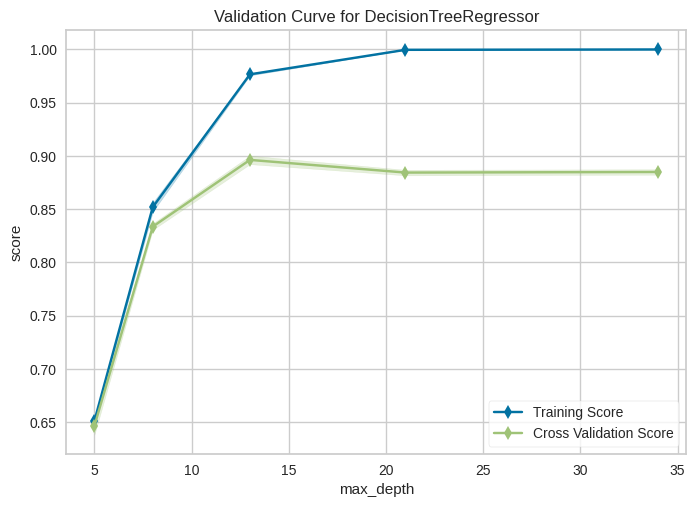

In [9]:
viz = ValidationCurve(
    DecisionTreeRegressor(), param_name="max_depth",
    param_range=[5, 8, 13, 21, 34], cv=5, scoring="r2",
    n_jobs=-1
)

viz.fit(X_train, y_train)
viz.show();

**Lecture :** quand `max_depth` augmente, on observe :

- Le score **train** continue de monter (l'arbre peut mémoriser de plus en plus).
- Le score **validation** plafonne, puis l'écart train/validation s'élargit → **variance croissante**, **overfitting**.

> **Zone à retenir pour le GridSearch :** on étudiera le comportement de l'algorithme pour $\mathit{max\_depth}$ **entre 13 et 34**, là où le score de validation est le plus élevé avant la dégradation.

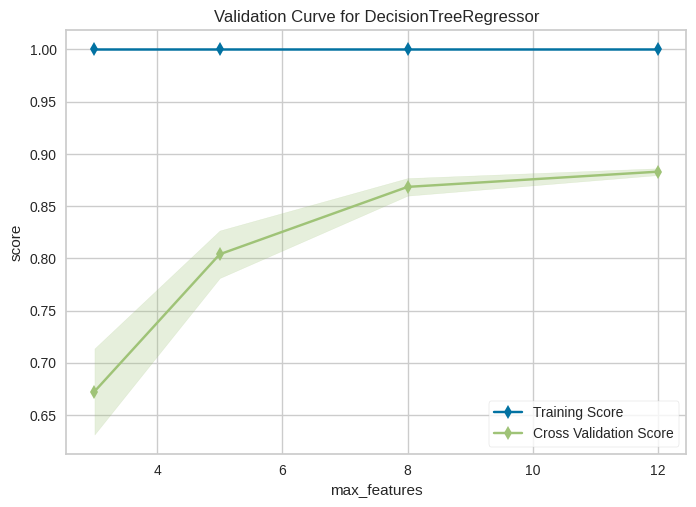

In [10]:
viz = ValidationCurve(
    DecisionTreeRegressor(), param_name="max_features",
    param_range=[3, 5, 8, 12], cv=5, scoring="r2",
    n_jobs=-1
)

viz.fit(X_train, y_train)
viz.show();

**Lecture :** à partir de $\mathit{max\_features} = 8$, le score de cross-validation se **stabilise** et son écart-type diminue (les courbes sont plus serrées). Le gap train/validation qu'on observe n'est donc **pas dû** à cet hyperparamètre — il vient des autres.

> **Décision :** on gardera l'ensemble des features (ou on fixera `max_features=12` dans la grille finale) — pas besoin de l'optimiser davantage.

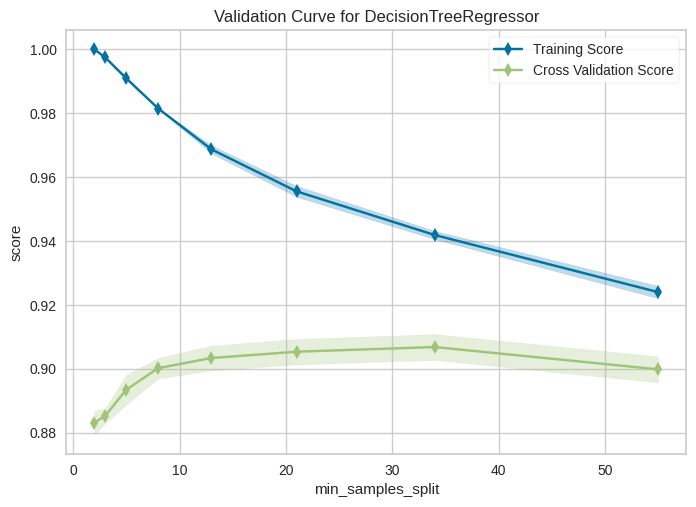

In [11]:
viz = ValidationCurve(
    DecisionTreeRegressor(), param_name="min_samples_split",
    param_range=[2, 3, 5, 8, 13, 21, 34, 55], cv=5, scoring="r2",
    n_jobs=-1
)

viz.fit(X_train, y_train)
viz.show();

**Lecture :** lorsque $\mathit{min\_samples\_split}$ croît (l'arbre exige plus d'échantillons pour autoriser une division) :

- Le **gap train/validation** diminue → la **variance** baisse (moins d'overfitting).
- Mais le score de train diminue aussi → le **biais** augmente (le modèle devient plus rigide).

C'est exactement le compromis biais-variance en action. On cherche le « point d'équilibre ».

> **Zone à retenir pour le GridSearch :** on gardera les valeurs de $\mathit{min\_samples\_split}$ **entre 20 et 40**.

### Utilisation de `GridSearchCV` avec les valeurs ciblées

Maintenant qu'on a identifié **les zones intéressantes** de chaque hyperparamètre grâce aux courbes de validation, on peut lancer un `GridSearchCV` **plus petit et plus ciblé** — donc plus rapide et plus informatif.

**Grille initiale** (section précédente) : 18 combinaisons × 10 folds = **180 entraînements**, exploration à l'aveugle.
**Grille ciblée** (ci-dessous) : 12 combinaisons × 10 folds = **120 entraînements**, sur les zones qu'on sait prometteuses.

In [12]:
param_grid = [
    { "min_samples_split": [20, 25, 34, 40], "max_depth": [13, 21, 34] }
]

tree_reg = DecisionTreeRegressor(random_state=2)
grid_search_tree_reg = GridSearchCV(
    tree_reg, param_grid, cv=10, scoring="r2", n_jobs=-1,
    return_train_score=True
)
grid_search_tree_reg.fit(X_train, y_train)

GridSearchCV(cv=10, estimator=DecisionTreeRegressor(random_state=2), n_jobs=-1,
             param_grid=[{'max_depth': [13, 21, 34],
                          'min_samples_split': [20, 25, 34, 40]}],
             return_train_score=True, scoring='r2')

In [13]:
display_cv_results(grid_search_tree_reg)

{'max_depth': 21, 'min_samples_split': 34} 0.9107765872018472 0.00865451554986175 0.9436111584209883 0.0014295278854909613
{'max_depth': 34, 'min_samples_split': 34} 0.9107763138110301 0.008654907540284801 0.9436116722751592 0.0014296583119658773
{'max_depth': 21, 'min_samples_split': 40} 0.9098162161771753 0.00791807179681839 0.938610705401177 0.0013058232499438681
{'max_depth': 34, 'min_samples_split': 40} 0.9098162161771753 0.00791807179681839 0.938610705401177 0.0013058232499438681
{'max_depth': 21, 'min_samples_split': 25} 0.9093588919815977 0.008523689228896108 0.9528315325724283 0.0013903627999012885
{'max_depth': 21, 'min_samples_split': 20} 0.909356903587135 0.00908844460185575 0.9578739188410503 0.0012671506701511953
{'max_depth': 34, 'min_samples_split': 25} 0.9091211755529722 0.008343050139337541 0.952837463827367 0.0013964226106053608
{'max_depth': 34, 'min_samples_split': 20} 0.9086390537071736 0.009032991915830083 0.9578873682657416 0.0012697652171297182
{'max_depth': 13

### Discussion

**Observations sur les résultats ciblés :**
- Les scores moyens de validation sont tous très proches (entre 0,907 et 0,911). C'est un **bon signe** — le modèle est robuste dans cette zone, il ne dépend pas d'une combinaison magique précise.
- Le gagnant : `max_depth=21, min_samples_split=34` avec un score de **0,9108**, et un gap train/test maîtrisé (0,9436 vs 0,9108).

**Questions à se poser :**
- **En quoi l'étude hyperparamètre par hyperparamètre aide-t-elle à limiter la plage ?**
  → Elle permet de repérer visuellement la zone utile et d'ignorer les plages inintéressantes, sans lancer des dizaines de combinaisons inutiles.

- **Quelles sont les limites de cette démarche ?**
  → Les courbes de validation étudient **un seul** hyperparamètre à la fois, en gardant les autres fixes. Or les hyperparamètres peuvent **interagir entre eux** : la valeur optimale de `max_depth` peut dépendre de `min_samples_split`. La démarche reste donc une **approximation** — elle aide à réduire la grille, mais ne garantit pas d'atteindre l'optimum global. C'est un compromis entre exhaustivité et temps de calcul.

- **Alternatives plus puissantes** (au-delà de ce notebook) : `RandomizedSearchCV` (tirages aléatoires dans la grille, souvent plus efficace que la recherche exhaustive), ou des outils d'**optimisation bayésienne** comme `Optuna` / `Hyperopt` qui apprennent des essais précédents pour mieux cibler les suivants.

## Rappel de la démarche complète

Pour résumer, voici la démarche type d'optimisation d'hyperparamètres avec scikit-learn. Les cellules ci-dessous illustrent chaque étape.

In [14]:
# Chargement des données


In [15]:
# Extraction des données de train et de test

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=2
)

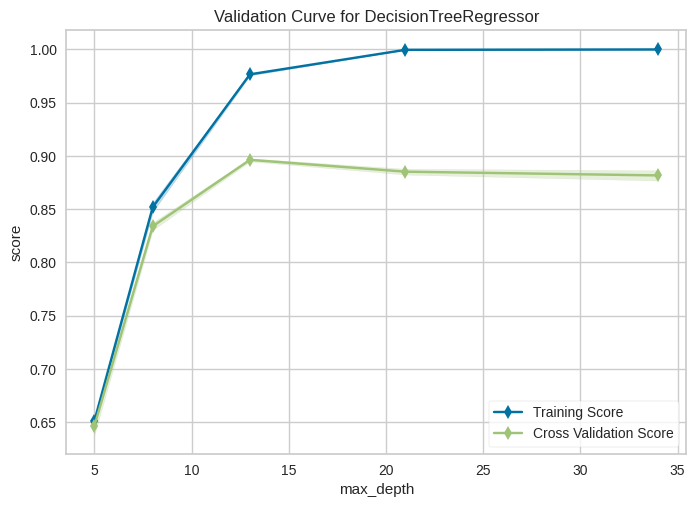

In [16]:
# Etude du comportement d'un sous-ensemble selectionné d'hyperparamètres

viz = ValidationCurve(
    DecisionTreeRegressor(), param_name="max_depth",
    param_range=[5, 8, 13, 21, 34], cv=5, scoring="r2",
    n_jobs=-1
)

viz.fit(X_train, y_train)
viz.show();

In [17]:
# Recherche d'un "optimum" grâce à GridSearchCV

param_grid = [
    { "max_depth": [8, 13, 21, 34], "max_features": [8, 12] },
    { "min_samples_split": [8, 13, 21, 34, 55], "max_features": [8, 13, 16] }
]

tree_reg = DecisionTreeRegressor(random_state=2)
grid_search_tree_reg = GridSearchCV(
    tree_reg, param_grid, cv=5, scoring="r2", 
    return_train_score=True
)
grid_search_tree_reg.fit(X_train, y_train)

/opt/conda/lib/python3.11/site-packages/numpy/ma/core.py:2846: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=2),
             param_grid=[{'max_depth': [8, 13, 21, 34],
                          'max_features': [8, 12]},
                         {'max_features': [8, 13, 16],
                          'min_samples_split': [8, 13, 21, 34, 55]}],
             return_train_score=True, scoring='r2')

In [18]:
# Exploitation du modèle obtenu sur les données ...

grid_search_tree_reg.best_estimator_

DecisionTreeRegressor(max_features=13, min_samples_split=34, random_state=2)

In [19]:
# ... Par exemple pour prédire les valeurs sur une ensemble de nouvelles données 

grid_search_tree_reg.predict(X_test)

array([  8.25      ,  26.6875    ,  50.4       , ...,  47.9375    ,
       171.1875    , 425.06666667])

## 🎯 En pratique — bien utiliser GridSearchCV

### La démarche type en 5 étapes

1. **Split train / test.** Le test reste scellé jusqu'à la toute fin.
2. **Études préliminaires (ValidationCurve).** Tracer les courbes hyperparamètre par hyperparamètre pour repérer les zones utiles. Ça évite de balayer à l'aveugle.
3. **GridSearchCV sur zones ciblées.** Grille réduite mais fine, avec cross-validation (`cv=5` ou `cv=10`).
4. **Analyse des résultats.** Regarder `best_params_`, mais aussi la **distribution** des top-5 / top-10 scores pour vérifier la stabilité.
5. **Évaluation finale sur le test set.** Avec `best_estimator_` (le modèle déjà réentraîné sur tout le train par `GridSearchCV`).

### Les pièges classiques

- ⚠️ **Data leakage dans le preprocessing.** Si tu normalises ou imputes les données **avant** `GridSearchCV`, tu fuites des informations du futur (validation) vers le passé (train). Utiliser systématiquement un `Pipeline` :
  ```python
  from sklearn.pipeline import Pipeline
  from sklearn.preprocessing import StandardScaler
  pipe = Pipeline([('scaler', StandardScaler()), ('model', DecisionTreeRegressor())])
  param_grid = {'model__max_depth': [5, 10, 20]}  # noter le préfixe 'model__'
  GridSearchCV(pipe, param_grid, cv=10).fit(X_train, y_train)
  ```
- ⚠️ **Explosion combinatoire.** Un grid avec 4 hyperparamètres × 5 valeurs chacun × 10 folds = **6 250 entraînements**. Ça devient vite irréaliste.
- ⚠️ **Biais de sélection.** Plus tu testes de combinaisons, plus tu risques d'en trouver une qui « marche bien par hasard » sur ton jeu de cross-validation. D'où l'importance du **test set final** scellé.
- ⚠️ **Métrique mal choisie.** `scoring="r2"` ne dit pas la même chose que `scoring="neg_mean_absolute_error"`. Une mauvaise métrique peut te faire choisir un modèle qui optimise la mauvaise chose.

### Alternatives à connaître

| Outil | Quand l'utiliser |
|---|---|
| **`GridSearchCV`** | Peu d'hyperparamètres, plages déjà ciblées |
| **`RandomizedSearchCV`** | Beaucoup d'hyperparamètres, on tire des combinaisons au hasard — souvent aussi bon que Grid pour un coût bien moindre |
| **`HalvingGridSearchCV` / `HalvingRandomSearchCV`** | Versions « tournoi » : les mauvaises combinaisons sont éliminées rapidement, les bonnes explorées plus finement |
| **`Optuna` / `Hyperopt`** | Optimisation bayésienne — apprend des essais précédents pour mieux cibler les suivants. État de l'art pour les modèles coûteux (deep learning, gradient boosting sur gros datasets) |

### À retenir

> **GridSearchCV automatise la cross-validation sur une grille d'hyperparamètres, mais ne remplace pas ton jugement.** La meilleure démarche reste : *(1)* comprendre l'effet de chaque hyperparamètre avec des courbes de validation, *(2)* cibler la grille, *(3)* lancer `GridSearchCV` *(4)* vérifier la stabilité des résultats, et *(5)* tester sur le test set final. C'est plus de travail qu'un simple `GridSearchCV` balayé à l'aveugle — mais c'est ce qui distingue un modèle fiable d'un modèle « qui marche par chance ».